<a href="https://colab.research.google.com/github/MaryumHayat/Internship/blob/main/Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
# STAGE 2: Data Collection & Error Logging
import os
from datetime import datetime
import pandas as pd

log_file_path = "pipeline_errors.log"

try:
    # keep_default_na=False keeps 'None' as a valid category for healthy individuals
    df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv", keep_default_na=False, na_values=[''])
    print("Dataset loaded successfully!")
    print(f"Shape of the dataset: {df.shape}\n")

    # Displays the beautiful interactive table only if the file loads perfectly
    display(df.head())

except Exception as e:
    error_msg = f"[{datetime.now()}] ERROR during data loading: {str(e)}\n"
    with open(log_file_path, "a") as f:
        f.write(error_msg)
    print(f"An error occurred. Details have been logged to '{log_file_path}'.")

Dataset loaded successfully!
Shape of the dataset: (374, 13)



,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [42]:
# STAGE 3: Data Preparation, Cleaning, & Local Storage
import os
import numpy as np
import pandas as pd

# 1. Explicitly check for missing/NULL values
print("--- 'Is Null' Column Audit ---")
null_counts = df.isnull().sum()
print(null_counts)

# Drop useless ID column
if 'Person ID' in df.columns:
    df = df.drop(columns=['Person ID'])

# Remove rows with actual missing target data (ignores 'None' text labels)
df = df.dropna(subset=['Sleep Disorder'])

# Fill numeric nulls with median values
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# 2. Save the cleaned version to a brand-new file in local memory
clean_file_path = "clean_data.csv"
df.to_csv(clean_file_path, index=False)
print(f"\nCleaned dataset exported successfully to local memory as '{clean_file_path}'!")

# 3. Read back and display the new file to verify integrity
print("\n--- Displaying Cleaned Data Head ---")
df_cleaned_preview = pd.read_csv(clean_file_path, keep_default_na=False)
display(df_cleaned_preview.head())


--- 'Is Null' Column Audit ---
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64

Cleaned dataset exported successfully to local memory as 'clean_data.csv'!

--- Displaying Cleaned Data Head ---


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [37]:
# STAGE 4: Feature Engineering
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_features = df.copy()

# Identify categorical variables
categorical_cols = df_features.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Sleep Disorder')

# Convert string columns into binary dummy variables
df_features = pd.get_dummies(df_features, columns=categorical_cols, drop_first=True)

# Encode target variable (Now preserves 'None', 'Insomnia', 'Sleep Apnea')
le_target = LabelEncoder()
df_features['Sleep Disorder'] = le_target.fit_transform(df_features['Sleep Disorder'])

# Domain-driven physiological engineering metrics
df_features['Sleep_Efficiency'] = df_features['Quality of Sleep'] / (df_features['Sleep Duration'] + 1e-5)
df_features['Stress_Impact'] = df_features['Stress Level'] * df_features['Heart Rate']

# Separate features (X) and target labels (y)
X = df_features.drop(columns=['Sleep Disorder'])
y = df_features['Sleep Disorder']

print("Features (X) headers passed to training:")
print(X.columns.tolist())

print("\nClass mappings for Target (y):")
for index, class_label in enumerate(le_target.classes_):
    print(f"Code {index} -> {class_label}")

Features (X) headers passed to training:
['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Gender_Male', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Nurse', 'Occupation_Sales Representative', 'Occupation_Salesperson', 'Occupation_Scientist', 'Occupation_Software Engineer', 'Occupation_Teacher', 'BMI Category_Normal Weight', 'BMI Category_Obese', 'BMI Category_Overweight', 'Blood Pressure_115/78', 'Blood Pressure_117/76', 'Blood Pressure_118/75', 'Blood Pressure_118/76', 'Blood Pressure_119/77', 'Blood Pressure_120/80', 'Blood Pressure_121/79', 'Blood Pressure_122/80', 'Blood Pressure_125/80', 'Blood Pressure_125/82', 'Blood Pressure_126/83', 'Blood Pressure_128/84', 'Blood Pressure_128/85', 'Blood Pressure_129/84', 'Blood Pressure_130/85', 'Blood Pressure_130/86', 'Blood Pressure_131/86', 'Blood Pressure_132/87', 'Blood Pressure_135/88', 'Blood Pressure_135/90', '

In [38]:
# STAGE 5: Training & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Split data: 25% testing, 75% training stratified by class distributions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}\n")

# Baseline Gradient Boosting setup
gb_base = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb_base.fit(X_train, y_train)
y_pred_base = gb_base.predict(X_test)

print(f"Baseline Test Accuracy: {accuracy_score(y_test, y_pred_base) * 100:.2f}%")

Training shape: (280, 47), Test shape: (94, 47)

Baseline Test Accuracy: 92.55%


In [39]:
# STAGE 6: Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 1.0]
}

print("Starting Hyperparameter Tuning Optimization...")

grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Optimal Hyperparameters Found: {grid_search.best_params_}")

Starting Hyperparameter Tuning Optimization...
Optimal Hyperparameters Found: {'learning_rate': 0.03, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}


================ CLASSIFICATION AUDIT REPORT ================
              precision    recall  f1-score   support

    Insomnia       0.89      0.89      0.89        19
        None       1.00      0.96      0.98        55
 Sleep Apnea       0.86      0.95      0.90        20

    accuracy                           0.95        94
   macro avg       0.92      0.94      0.93        94
weighted avg       0.95      0.95      0.95        94



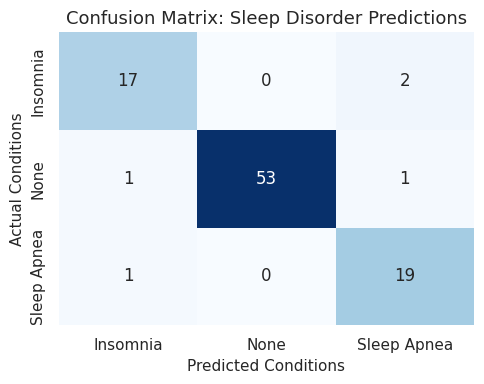

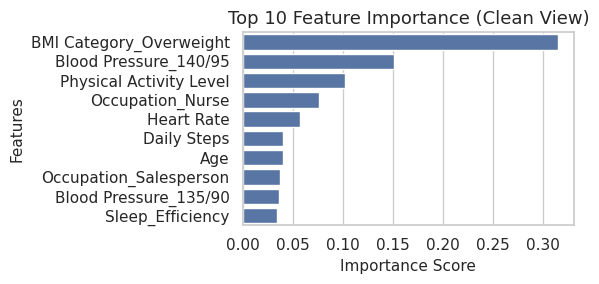

In [40]:
# STAGE 7: Evaluation Metrics & Diagnostic Audits
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

%matplotlib inline
sns.set_theme(style="whitegrid")

y_pred = best_model.predict(X_test)

print("================ CLASSIFICATION AUDIT REPORT ================")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Generate and display Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=le_target.classes_, yticklabels=le_target.classes_,
    annot_kws={"size": 12}
)
plt.title('Confusion Matrix: Sleep Disorder Predictions', fontsize=13)
plt.ylabel('Actual Conditions', fontsize=11)
plt.xlabel('Predicted Conditions', fontsize=11)
plt.tight_layout()
plt.show()

# Extract and isolate Top 10 Feature Importances
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

top_n = 10
top_features = X.columns[indices][:top_n]
top_importances = importances[indices][:top_n]

plt.figure(figsize=(6, 3))
sns.barplot(x=top_importances, y=top_features)
plt.title("Top 10 Feature Importance (Clean View)", fontsize=13)
plt.xlabel("Importance Score", fontsize=11)
plt.ylabel("Features", fontsize=11)
plt.tight_layout()
plt.show()

In [41]:
import pickle

# Save model
with open("sleep_disorder_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save label encoder (VERY IMPORTANT)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le_target, f)

# Save feature columns (to align input later)
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully!")

Model saved successfully!
